# DeepSVDD — 一分类异常检测用于 CN 增峰星筛选

**核心思路**: 用大量未标注恒星光谱训练 DeepSVDD，学习"正常光谱"的紧致表示。
训练完成后，已知 CN 增峰星（来自 CNstar + FT_cands + GCS 三个来源）应当具有更高的异常分数。

使用 **完整 LAMOST 光谱**（3700–9000Å，覆盖蓝端+红端），便于后续通过其他谱线辅助证认。

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import warnings
warnings.filterwarnings('ignore')

# Add project root
_root = os.path.dirname(os.getcwd()) if 'Deep' in os.getcwd() else os.getcwd()
if _root not in sys.path:
    sys.path.insert(0, _root)

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

PyTorch: 2.5.1+cu121
CUDA available: True


In [2]:
from Deep.config import DeepSVDDConfig
from Deep.data import load_spectra_data, create_dataloaders
from Deep.models import DeepSVDD
from Deep.train import DeepSVDDTrainer
from Deep.evaluate import evaluate_model, select_candidates, summarize_results

print('Modules loaded successfully')

Modules loaded successfully


## 1. 数据加载

使用 `spectra_io.py` 的完整预处理管线：坐标匹配 → FITS 读取 → 归一化 → 去重 → 异常过滤

In [3]:
os.chdir(_root)  # 切换到项目根目录以确保相对路径有效

dataset = load_spectra_data(
    stars_csv='stars.csv',
    spectra_folder='dr13_new',
    # 默认使用 CNstar + FT_cands + GCS 三个来源
    verbose=True,
)

print(f'\nSpectra shape: {dataset.X.shape}')
print(f'Known CN stars: {dataset.n_positive}')
print(f'Unlabeled: {dataset.n_unlabeled}')
print(f'Wavelength range: {dataset.wave[0]:.0f} - {dataset.wave[-1]:.0f} A')

Loading LAMOST spectra (segment normalisation)
  Catalog: 48440 stars, 108 labeled CN
  Wavelength grid: 3710-8889 A (5180 px)
  Loaded: 37086 spectra


Segment norm: 100%|██████████| 37086/37086 [01:14<00:00, 495.53it/s]


  After norm QC: 37086 spectra
  After dedup: 34123 spectra
  After anomaly filter: 33512 spectra
  CN positive: 73
  Unlabeled:   33439

Spectra shape: (33512, 5180)
Known CN stars: 73
Unlabeled: 33439
Wavelength range: 3710 - 8889 A


## 2. DeepSVDD 配置

关键参数：
- **one-class** objective: 最小化到中心的平均距离（更稳定）
- **soft-boundary**: 包含 nu 参数控制边界松紧度

In [4]:
config = DeepSVDDConfig(
    input_dim=dataset.n_features,            # 完整光谱像素数（3700-9000A = 5300）
    latent_dim=32,                           # 潜在表示维度
    dropout=0.2,
    objective='one-class',                   # 更稳定的目标函数
    learning_rate=1e-4,
    batch_size=128,                          # 完整光谱需要更小 batch
    n_epochs=150,
    early_stopping_patience=30,
    weight_decay=1e-6,
    random_seed=42,
    device='cuda' if torch.cuda.is_available() else 'cpu',
)

print(f'Device: {config.device}')
print(f'Architecture: {config.input_dim} -> {" → ".join(map(str, config.hidden_dims))} -> {config.latent_dim}')

Device: cuda
Architecture: 5180 -> 512 → 256 → 128 → 64 -> 32


## 3. 训练 DeepSVDD

In [5]:
trainer = DeepSVDDTrainer(config, save_dir='Deep/checkpoints')
model = trainer.train(dataset, verbose=True)

CN pre-clean: threshold=0.4537, removed 1672 unlabeled (5.0%), known-CN median=0.4423
  Train samples (clean): 28,591 / 33,439 unlabeled
Model: 381,600 parameters
  Input: 5180
  Hidden: [512, 256, 128, 64]
  Latent: 32
  Encoder: conv1d
  Objective: one-class
Initializing hypersphere center...

Training for up to 150 epochs...
  Train samples: 28591
------------------------------------------------------------
Epoch  10/150 | loss: 0.0056 | val_loss: 0.0006 | lr: 1.00e-04
Epoch  20/150 | loss: 0.0034 | val_loss: 0.0004 | lr: 1.00e-04
Epoch  30/150 | loss: 0.0024 | val_loss: 0.0001 | lr: 1.00e-04
Epoch  40/150 | loss: 0.0020 | val_loss: 0.0001 | lr: 5.00e-05 *
Epoch  50/150 | loss: 0.0018 | val_loss: 0.0001 | lr: 5.00e-05
Epoch  60/150 | loss: 0.0018 | val_loss: 0.0001 | lr: 5.00e-05
Epoch  70/150 | loss: 0.0017 | val_loss: 0.0001 | lr: 5.00e-05
Epoch  80/150 | loss: 0.0017 | val_loss: 0.0002 | lr: 2.50e-05
Epoch  90/150 | loss: 0.0017 | val_loss: 0.0001 | lr: 2.50e-05
Epoch 100/150 | l

### 训练历史

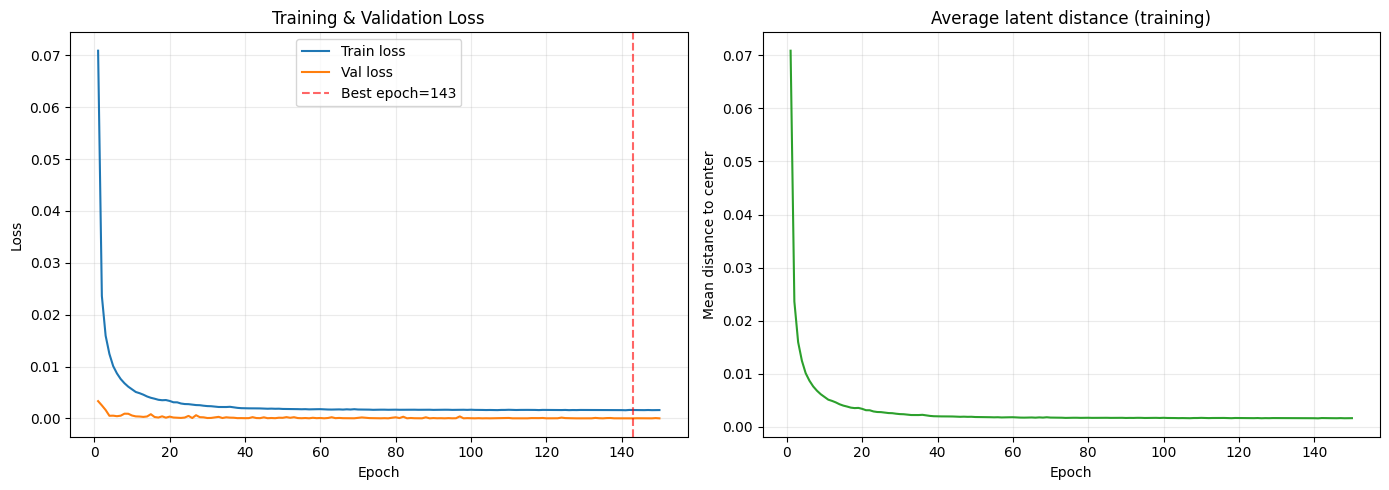

In [6]:
history_df = trainer.get_history_df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train loss', color='tab:blue')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='Val loss', color='tab:orange')
best_epoch = history_df.loc[history_df['val_loss'].idxmin(), 'epoch']
axes[0].axvline(best_epoch, color='red', linestyle='--', alpha=0.6, label=f'Best epoch={best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_dist_mean'], color='tab:green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean distance to center')
axes[1].set_title('Average latent distance (training)')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 4. 评估：已知 CN 星的异常分数

In [7]:
metrics = evaluate_model(model, dataset, device=config.device)
print(summarize_results(metrics))

DeepSVDD Evaluation Results
Total samples:       33,512
Known CN stars:      73

--- Separation Metrics ---
AUROC:               0.4495
AUPRC:               0.0019
Median rank (pos):   0.5812 (lower = better, random = 0.5)

--- Top-K Precision ---
  precision@ 50:     0.0000  (recall: 0.0000)
  precision@100:     0.0000  (recall: 0.0000)
  precision@200:     0.0000  (recall: 0.0000)

--- Anomaly Score Statistics ---
  Known CN — mean:   0.0000, std: 0.0000
  Unlabeled — mean:  0.0000, std: 0.0000


### 异常分数分布

理想情况：已知 CN 星（橙色）的异常分数明显高于未标注背景星（灰色）。

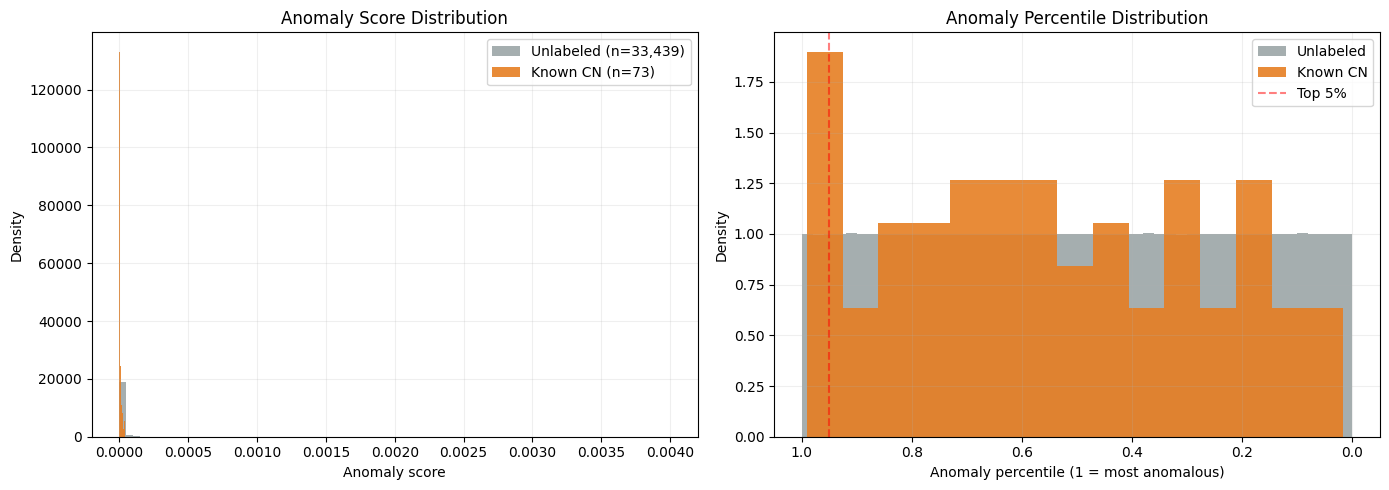

KS test: statistic=0.0980, p-value=4.56e-01


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(metrics['scores_unlabeled'], bins=80, density=True, alpha=0.7,
        color='#7f8c8d', label=f'Unlabeled (n={len(metrics["scores_unlabeled"]):,})')
ax.hist(metrics['scores_positive'], bins=20, density=True, alpha=0.9,
        color='#e67e22', label=f'Known CN (n={len(metrics["scores_positive"])})')
ax.set_xlabel('Anomaly score')
ax.set_ylabel('Density')
ax.set_title('Anomaly Score Distribution')
ax.legend()
ax.grid(alpha=0.2)

# Rank percentile
ax = axes[1]
pos_pct = 1.0 - metrics['scores_all'].argsort().argsort() / len(metrics['scores_all'])
pos_mask = dataset.y == 1
ax.hist(pos_pct[~pos_mask], bins=50, density=True, alpha=0.7,
        color='#7f8c8d', label='Unlabeled')
ax.hist(pos_pct[pos_mask], bins=15, density=True, alpha=0.9,
        color='#e67e22', label='Known CN')
ax.axvline(0.95, color='red', linestyle='--', alpha=0.5, label='Top 5%')
ax.set_xlabel('Anomaly percentile (1 = most anomalous)')
ax.set_ylabel('Density')
ax.set_title('Anomaly Percentile Distribution')
ax.invert_xaxis()
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# KS test: are the distributions different?
from scipy.stats import ks_2samp
ks_stat, ks_pval = ks_2samp(metrics['scores_positive'], metrics['scores_unlabeled'])
print(f'KS test: statistic={ks_stat:.4f}, p-value={ks_pval:.2e}')

## 5. Top 候选星

In [9]:
candidates = select_candidates(metrics, top_n=200,
    output_csv='Deep/candidates_deep_svdd.csv')
print(f'Top 20 candidates:')
display(candidates.head(20)[['anomaly_score', 'teff', 'logg', 'feh', 'snru']])

Top 20 candidates:


,anomaly_score,teff,logg,feh,snru
10795,0.004000,5116.79,2.936,-1.028,15.11
29017,0.002989,4924.67,2.942,-0.701,7.90
1370,0.002449,4466.80,1.339,-1.149,8.53
24821,0.002033,5042.60,2.208,-1.765,17.91
866,0.001595,4249.72,0.624,-1.747,11.99
29612,0.001378,5073.90,2.689,-1.533,6.92
8930,0.001187,4997.19,2.426,-0.752,18.19
7437,0.001132,4977.49,2.921,-0.859,5.13
31130,0.001053,4547.69,2.017,-1.137,14.66
32726,0.000913,4830.74,1.819,-1.005,6.56


### 候选星在 Teff-Logg 空间分布

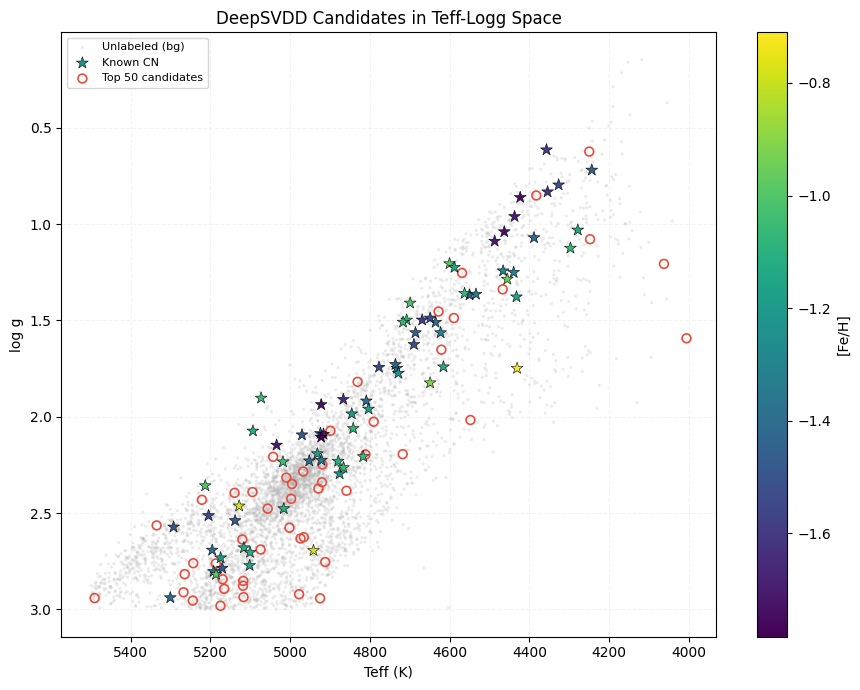

In [10]:
meta = dataset.meta.copy()
known_cn = meta[meta['label'] == 1]
bg = meta[meta['label'] == -1]

fig, ax = plt.subplots(figsize=(9, 7))

if len(bg) > 5000:
    bg_plot = bg.sample(5000, random_state=42)
else:
    bg_plot = bg

ax.scatter(bg_plot['teff'], bg_plot['logg'], s=5, c='#b0b0b0', alpha=0.25,
           edgecolors='none', label='Unlabeled (bg)')
sc = ax.scatter(known_cn['teff'], known_cn['logg'], c=known_cn['feh'], cmap='viridis',
                s=80, marker='*', edgecolors='black', linewidth=0.4, label='Known CN', zorder=3)

# Top candidates
cand_top = candidates.head(50)
ax.scatter(cand_top['teff'], cand_top['logg'], facecolors='none',
           edgecolors='#e74c3c', s=40, linewidths=1.2, label='Top 50 candidates', zorder=2)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('[Fe/H]')
ax.set_xlabel('Teff (K)')
ax.set_ylabel('log g')
ax.set_title('DeepSVDD Candidates in Teff-Logg Space')
ax.invert_xaxis()
ax.invert_yaxis()
ax.legend(fontsize=8)
ax.grid(alpha=0.15, linestyle='--')
plt.tight_layout()
plt.show()

## 6. 候选光谱可视化

对比候选星的光谱与所在聚类平均光谱。

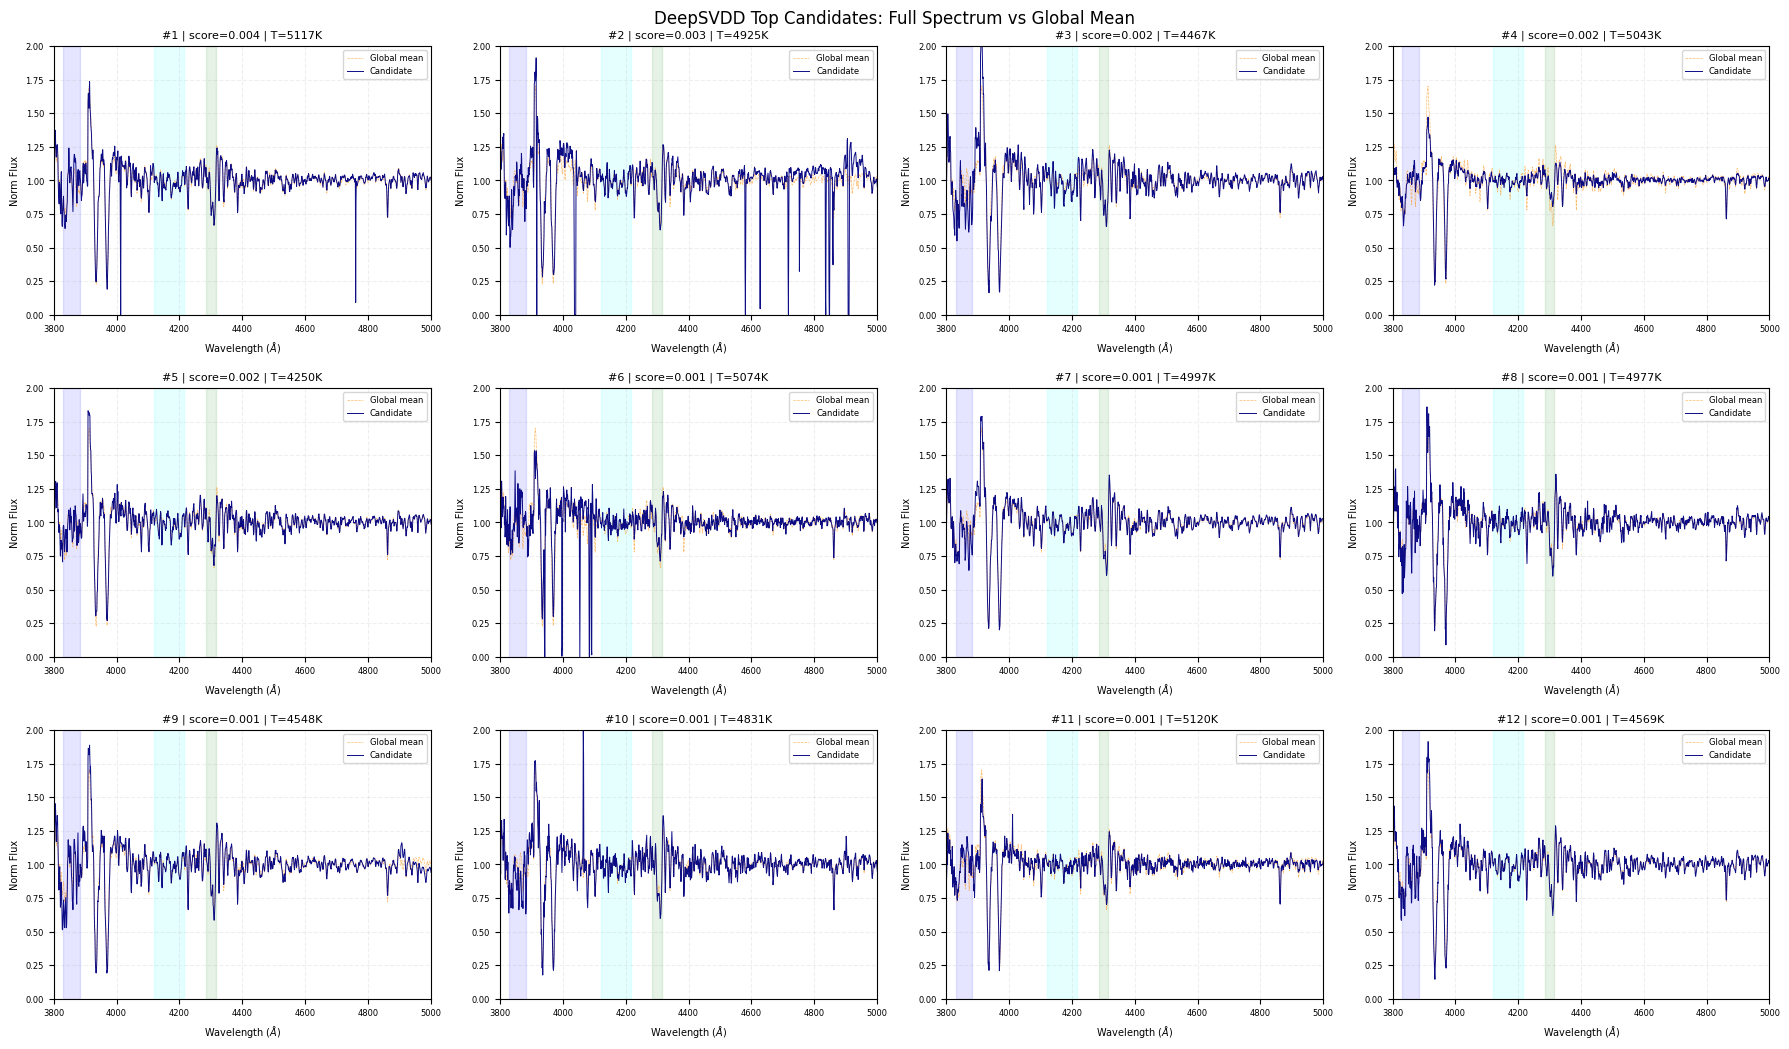

In [11]:
TOP_N = 12

# 计算全局平均光谱（作为参考标准）
global_mean = dataset.X.mean(axis=0)

cand_viz = candidates.head(TOP_N).copy()

n_cols = 4
n_rows = int(np.ceil(TOP_N / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.5 * n_rows))
axes = np.asarray(axes).reshape(-1)

for i, (_, row) in enumerate(cand_viz.iterrows()):
    ax = axes[i]
    idx = row.name if hasattr(row, 'name') else i

    # CN/CH 分子带
    ax.axvspan(3830, 3883, alpha=0.10, color='blue', zorder=0)
    ax.axvspan(4120, 4216, alpha=0.10, color='cyan', zorder=0)
    ax.axvspan(4285, 4315, alpha=0.10, color='green', zorder=0)
    # 辅助证认特征
    ax.axvspan(5160, 5190, alpha=0.08, color='orange', zorder=0)  # Mg b triplet
    ax.axvspan(5880, 5910, alpha=0.08, color='red', zorder=0)     # Na D
    ax.axvspan(8480, 8670, alpha=0.08, color='purple', zorder=0)  # Ca II triplet

    # Global mean
    ax.plot(dataset.wave, global_mean, color='darkorange', linewidth=0.5,
            linestyle='--', alpha=0.6, label='Global mean', zorder=1)

    # Candidate spectrum
    if idx < len(dataset.X):
        ax.plot(dataset.wave, dataset.X[idx], color='navy', linewidth=0.7,
                alpha=0.95, label='Candidate', zorder=2)

    score = row.get('anomaly_score', np.nan)
    teff = row.get('teff', np.nan)
    logg = row.get('logg', np.nan)
    ax.set_title(f'#{i+1} | score={score:.3f} | T={teff:.0f}K', fontsize=8)
    ax.set_xlabel('Wavelength ($\\AA$)', fontsize=7)
    ax.set_ylabel('Norm Flux', fontsize=7)
    ax.set_ylim(0, 2)
    ax.set_xlim(3800,5000)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.2, linestyle='--')
    ax.legend(fontsize=6, loc='upper right')

for j in range(len(cand_viz), len(axes)):
    axes[j].axis('off')

fig.suptitle('DeepSVDD Top Candidates: Full Spectrum vs Global Mean', fontsize=12, y=0.995)
plt.tight_layout()
plt.subplots_adjust(top=0.96)
plt.show()

## 7. Latent Space Visualization (t-SNE)

用 t-SNE 可视化 DeepSVDD 学到的潜在表示，观察已知 CN 星在潜在空间中的分布。

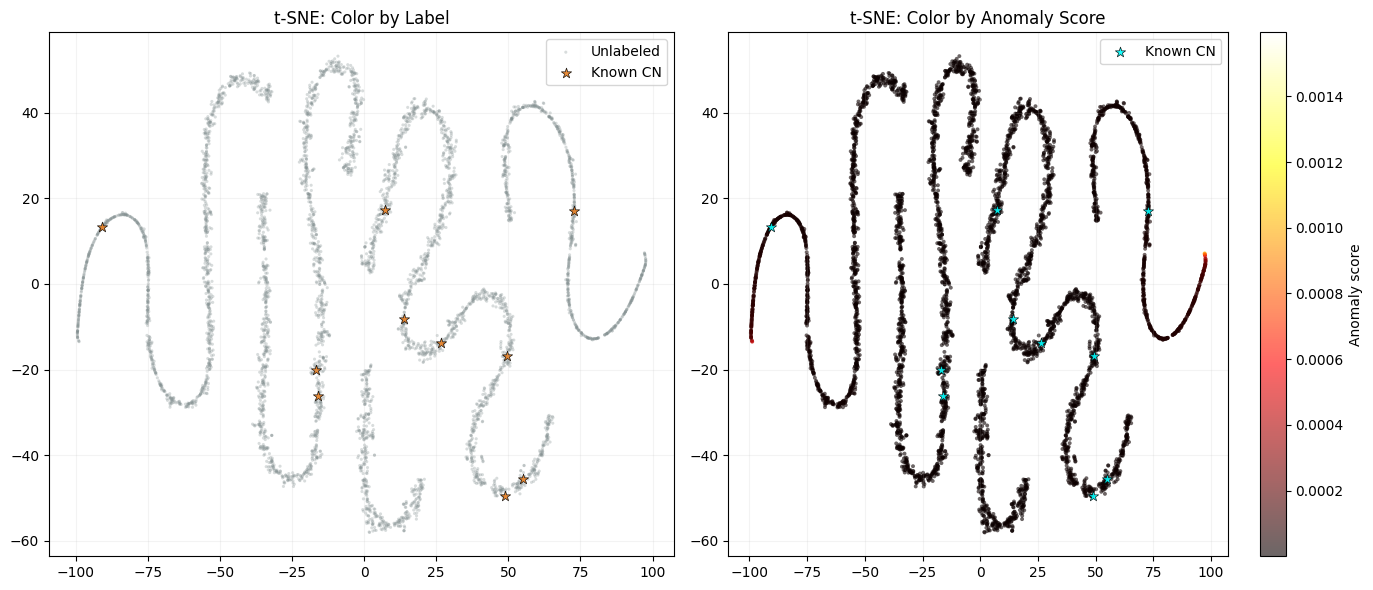

In [12]:
from sklearn.manifold import TSNE

# Compute latent representations for a subset
n_subset = min(5000, len(dataset.X))
rng = np.random.RandomState(42)
subset_idx = rng.choice(len(dataset.X), size=n_subset, replace=False)

X_subset = torch.from_numpy(dataset.X[subset_idx].astype(np.float32)) \
                .to(config.device)
model.to(config.device)
model.eval()

with torch.no_grad():
    latents = model.encoder(X_subset).cpu().numpy()

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latents_2d = tsne.fit_transform(latents)

# Score for subset
subset_scores = metrics['scores_all'][subset_idx]
subset_labels = dataset.y[subset_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Color by label
ax = axes[0]
unl_mask = subset_labels == -1
ax.scatter(latents_2d[unl_mask, 0], latents_2d[unl_mask, 1],
           s=5, c='#7f8c8d', alpha=0.3, edgecolors='none', label='Unlabeled')
pos_mask = subset_labels == 1
ax.scatter(latents_2d[pos_mask, 0], latents_2d[pos_mask, 1],
           s=60, c='#e67e22', marker='*', edgecolors='black', linewidth=0.5,
           alpha=0.9, label='Known CN')
ax.set_title('t-SNE: Color by Label')
ax.legend()
ax.grid(alpha=0.15)

# Color by anomaly score
ax = axes[1]
sc2 = ax.scatter(latents_2d[:, 0], latents_2d[:, 1],
                  s=8, c=subset_scores, cmap='hot', alpha=0.6, edgecolors='none')
ax.scatter(latents_2d[pos_mask, 0], latents_2d[pos_mask, 1],
           s=60, c='cyan', marker='*', edgecolors='black', linewidth=0.5,
           alpha=0.9, label='Known CN')
cbar = plt.colorbar(sc2, ax=ax)
cbar.set_label('Anomaly score')
ax.set_title('t-SNE: Color by Anomaly Score')
ax.legend()
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

## 8. 对比实验：不同 latent_dim 的影响


Training with latent_dim=16...

Training with latent_dim=32...

Training with latent_dim=64...

Training with latent_dim=128...

Latent dim comparison (full spectrum):


,latent_dim,auroc,auprc,precision@50,precision@100,median_rank_pct,best_epoch
0,16,0.4020,0.0017,0.0,0.0,0.6286,78
1,32,0.5456,0.0024,0.0,0.0,0.4210,80
2,64,0.5323,0.0023,0.0,0.0,0.4834,80
3,128,0.4627,0.0020,0.0,0.0,0.5307,80


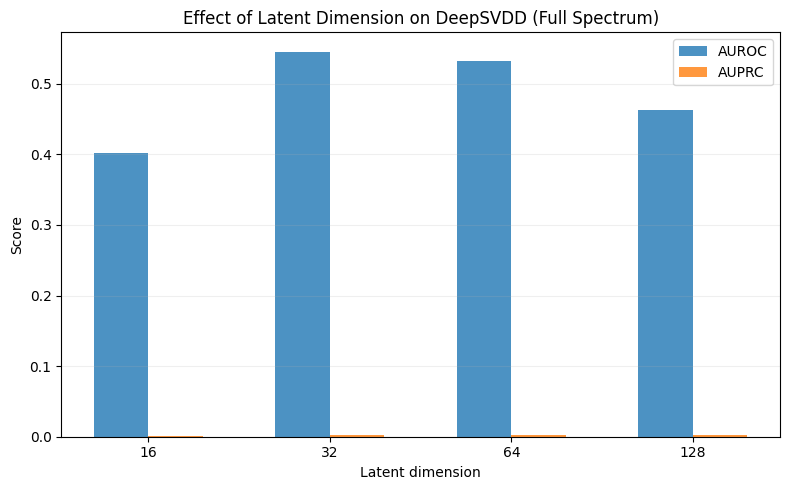

In [13]:
latent_dims = [16, 32, 64, 128]
comparison_results = []

for ld in latent_dims:
    print(f'\nTraining with latent_dim={ld}...')

    cfg = DeepSVDDConfig(
        input_dim=dataset.n_features,
        latent_dim=ld,
        n_epochs=80,
        early_stopping_patience=15,
        random_seed=42,
        device=config.device,
    )

    t = DeepSVDDTrainer(cfg, save_dir=f'Deep/checkpoints/ld_{ld}')
    m = t.train(dataset, verbose=False)
    met = evaluate_model(m, dataset, device=config.device)

    comparison_results.append({
        'latent_dim': ld,
        'auroc': met['auroc'],
        'auprc': met['auprc'],
        'precision@50': met['precision@50'],
        'precision@100': met['precision@100'],
        'median_rank_pct': met['median_rank_pct'],
        'best_epoch': t.history[-1]['epoch'] if t.history else None,
    })

# Display
comp_df = pd.DataFrame(comparison_results)
print('\nLatent dim comparison (full spectrum):')
display(comp_df.round(4))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comp_df))
w = 0.3
ax.bar(x - w/2, comp_df['auroc'], w, color='tab:blue', alpha=0.8, label='AUROC')
ax.bar(x + w/2, comp_df['auprc'], w, color='tab:orange', alpha=0.8, label='AUPRC')
ax.set_xticks(x)
ax.set_xticklabels(comp_df['latent_dim'])
ax.set_xlabel('Latent dimension')
ax.set_ylabel('Score')
ax.set_title('Effect of Latent Dimension on DeepSVDD (Full Spectrum)')
ax.legend()
ax.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.show()